In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib as mpl
from eval.data import load_and_split
from medal.model import AutoEncoder
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
from pathlib import Path
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-06 23:56:20,973	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-06 23:56:23,321	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# Set MEDAL_DATA_DIR to your drd_data directory
import os
PATH_PREFIX = os.environ.get('MEDAL_DATA_DIR', os.path.join(os.path.expanduser('~'), 'drd_data'))
# loading AE
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False, 
                    activation=torch.nn.SELU, bottleneck_activation = None, dropout_rate=0.1):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            # match training!
        bottleneck_activation=bottleneck_activation,
        use_batchnorm = batchnorm,
        dropout_rate = dropout_rate
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}
    

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

In [3]:
mnist_distill0 = []
mnist_distill0_embeddings = []
mnist_per_sample_distill0 = []
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, _, y, _ = train_test_split(X, y, test_size=0.2, random_state=0)
teacher_embed = np.load(Path(PATH_PREFIX) / f'embeddings2/mnist_tsne_18_0_train.npy')
for c in range(3):
    student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/inter/mnist/medal_tsne2_18_tc0_0_ckpts/band{c}.pt",
            input_dim=784,
            hidden_dims=[512, 512, 512, 512],
            latent_dim=2)
    
    _, student_embed = student(torch.tensor(X, dtype=torch.float32))
    train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2)
    per_sample_train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2, axis=1)
    mnist_distill0.append(train_distill)
    mnist_distill0_embeddings.append(student_embed.detach().numpy())
    mnist_per_sample_distill0.append(per_sample_train_distill)

student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/inter/mnist/medal_tsne2_18_tc0_0_ckpts/final.pt",
        input_dim=784,
        hidden_dims=[512, 512, 512, 512],
        latent_dim=2)

_, student_embed = student(torch.tensor(X, dtype=torch.float32))
train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2)
per_sample_train_distill = np.mean((student_embed.detach().numpy() - teacher_embed)**2, axis=1)
mnist_distill0.append(train_distill)
mnist_distill0_embeddings.append(student_embed.detach().numpy())
mnist_per_sample_distill0.append(per_sample_train_distill)

/tmp/ipykernel_24227/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_24227/1791026307.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("BuPu")


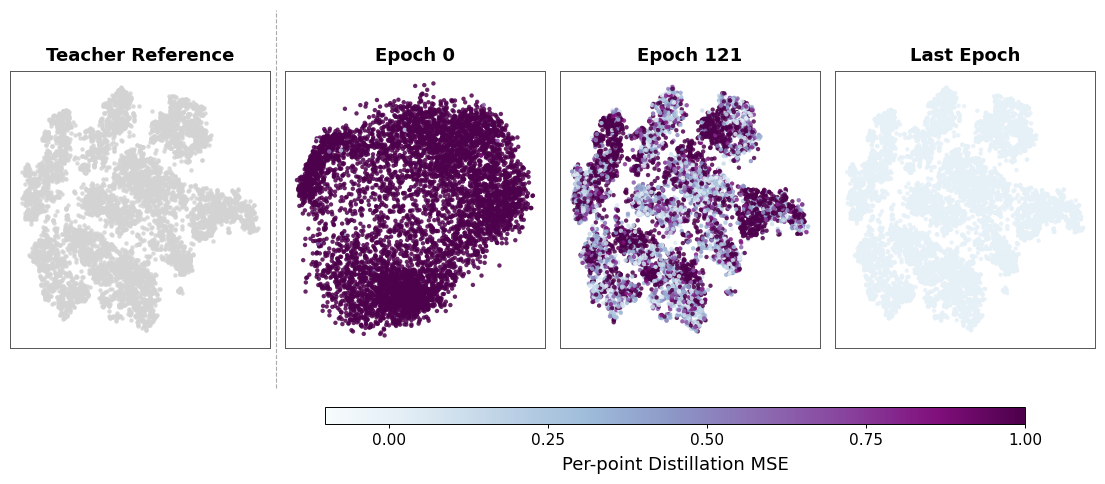

In [31]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# ── Journal-ready rcParams ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica Neue", "DejaVu Sans"],
    "font.size":          11,
    "axes.labelsize":     12,
    "axes.titlesize":     13,
    "axes.linewidth":     0.8,
    "xtick.major.width":  0.8,
    "ytick.major.width":  0.8,
    "figure.titlesize":   15,
    "figure.titleweight": "bold",
})

# ── Colormap: plasma_r (perceptually uniform, colorblind-safe) ──────────────
#    Low MSE → bright yellow  |  High MSE → dark purple  (intuitive for error)
cmap = plt.cm.get_cmap("BuPu")
norm = mpl.colors.Normalize(vmin=-0.1, vmax=1)

POINT_SIZE   = 10    # bigger points → structure visible at print size
POINT_ALPHA  = 0.85
LINEWIDTH    = 0.0   # no edge on markers

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
fig.subplots_adjust(wspace=0.06)

scatter_kw = dict(palette=cmap, hue_norm=norm, legend=None,
                  s=POINT_SIZE, alpha=POINT_ALPHA, linewidth=LINEWIDTH)
teacher_scatter_kw = dict(legend=None,
                  s=POINT_SIZE, alpha=POINT_ALPHA, linewidth=LINEWIDTH)

# ── Panels ──────────────────────────────────────────────────────────────────
panel_data = [
    (teacher_embed,                       np.zeros(len(teacher_embed)),        "Teacher Reference"),
    (mnist_distill0_embeddings[0],        mnist_per_sample_distill0[0],        "Epoch 0"),
    (mnist_distill0_embeddings[2],        mnist_per_sample_distill0[2],        "Epoch 121"),
    (mnist_distill0_embeddings[-1],       mnist_per_sample_distill0[-1],       "Last Epoch"),
]

for i, (ax, (embed, hue, title)) in enumerate(zip(axes, panel_data)):
    if i == 0:
        sns.scatterplot(x=embed[:, 0], y=embed[:, 1], color='#D3D3D3', ax=ax, **teacher_scatter_kw)        
    else:    
        sns.scatterplot(x=embed[:, 0], y=embed[:, 1], hue=hue, ax=ax, **scatter_kw)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=7)
    ax.set_xticks([]);  ax.set_yticks([])

    # Thinner, cleaner border
    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("#555555")

# ── Colorbar ─────────────────────────────────────────────────────────────────
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Centered below the four panels
cax = fig.add_axes([0.35, -0.10, 0.50, 0.045])   # [left, bottom, width, height]
cb  = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Per-point Distillation MSE", fontsize=13, labelpad=6)
cb.ax.tick_params(labelsize=11, width=0.7, length=3)
cb.outline.set_linewidth(0.7)
cb.set_ticks([0, 0.25, 0.50, 0.75, 1.0])

fig.add_artist(mpl.lines.Line2D(
    [0.315, 0.315], [0.0, 1.05],   # x in figure coords, between panel 1 and 2
    transform=fig.transFigure,
    color="#aaaaaa", linewidth=0.8, linestyle="--"
))

# ── Title & save ─────────────────────────────────────────────────────────────
# fig.suptitle("Distillation Progression to a t-SNE Teacher",
#              fontsize=20, fontweight=None, y=1.1)

plt.show()

In [3]:
mnist_res_dict = []
mnist_test_res_dict = []
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X, y, test_size=0.2, random_state=0)
for s in range(5):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 10).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/vanillaAE_{c}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=c, batchnorm=False)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "vanilla AE"})

#         student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/medal_umap{c}_18_0.1_tc0_{s}_ckpts/final.pt",
#                 input_dim=784,
#                 hidden_dims=[512, 512, 512, 512],
#                 latent_dim=c, batchnorm=False)
        
#         student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
#         train_recon = np.mean((student_recon.detach().numpy() - X)**2)
#         mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL + UMAP"})
#         x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
#         test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
#         mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL + UMAP"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})
        X_hat = pca.inverse_transform(pca.transform(X_test))
        test_recon = ((X_test - X_hat)**2).mean()
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/medal_pca{c}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=c, batchnorm=False)
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL (PCA teacher)"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL (PCA teacher)"})

#         student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/medal_spectral{c}_18_tc0_{s}_ckpts/final.pt",
#                 input_dim=784,
#                 hidden_dims=[512, 512, 512, 512],
#                 latent_dim=c, batchnorm=False)
        
#         student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
#         train_recon = np.mean((student_recon.detach().numpy() - X)**2)
#         mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL + Spectral"})
#         x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
#         test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
#         mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL + Spectral"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/mnist/linearAE_pca{c}_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=c, activation=None, batchnorm=False, dropout_rate=0)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        mnist_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL Linear AE (PCA teacher)"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        mnist_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL Linear AE (PCA teacher)"})

/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


...

loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_9977/1894101382.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


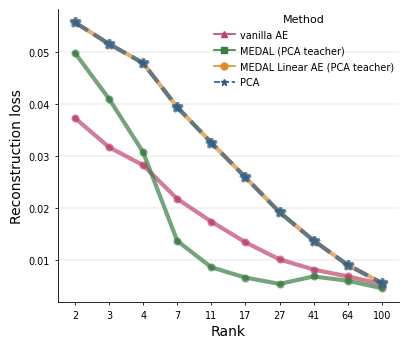

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# --- PNAS style setup ---
plt.rcParams.update({
    'font.family':            'sans-serif',
    'font.sans-serif':        ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'font.size':              8,
    'axes.labelsize':         8,
    'axes.titlesize':         9,
    'xtick.labelsize':        7,
    'ytick.labelsize':        7,
    'legend.fontsize':        7,
    'legend.title_fontsize':  8,
    'axes.linewidth':         0.6,
    'xtick.major.width':      0.6,
    'ytick.major.width':      0.6,
    'xtick.major.size':       2.5,
    'ytick.major.size':       2.5,
    'lines.linewidth':        1.2,
    'lines.markersize':       3.5,
    'pdf.fonttype':           42,
    'ps.fonttype':            42,
})

analysis      = pd.DataFrame(mnist_res_dict)
analysis      = analysis[~analysis.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]
analysis_test = pd.DataFrame(mnist_test_res_dict)
analysis_test = analysis_test[~analysis_test.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]

palette = {
    'vanilla AE':            '#C0446A',
    'MEDAL (PCA teacher)':           '#3A7D44',
    'MEDAL Linear AE (PCA teacher)': '#E08B2A',
    'PCA':                   '#2C5F8A',
}

markers = {
    'vanilla AE':            '^',
    'MEDAL (PCA teacher)':           's',
    'MEDAL Linear AE (PCA teacher)': 'o',
    'PCA':                   '*',
}

fig, ax = plt.subplots(1, 1, figsize=(4, 3.4))

sns.pointplot(
    data=analysis[analysis['method'] != 'PCA'],
    x='n_components', y='recon_loss',
    hue='method', palette=palette,
    errorbar='se', err_kws={'linewidth': 0.6},
    markersize=3.5, linewidth=3,
    dodge=False, legend=False, ax=ax, alpha=0.7
)
sns.pointplot(
    data=analysis[analysis['method'] == 'PCA'],
    x='n_components', y='recon_loss',
    hue='method', palette=palette,
    markersize=7, linewidth=3,alpha=0.7,
    legend=False, ax=ax,
    markers='*', linestyles='--',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('Rank', labelpad=3, fontsize=10)
ax.set_ylabel('Reconstruction loss', labelpad=3, fontsize=10)

legend_handles = []
for method, color in palette.items():
    ls = '--' if method == 'PCA' else '-'
    mk = markers[method]
    legend_handles.append(
        Line2D([0], [0], color=color, marker=mk,
               markersize=5, linewidth=1.2,
               linestyle=ls, label=method)
    )

ax.legend(
    handles=legend_handles,
    loc='upper right',
    frameon=False,
    title='Method',
    handlelength=2.2,
    handletextpad=0.5,
    borderpad=0,
    labelspacing=0.6,
)

plt.tight_layout(pad=0.5)
plt.show()

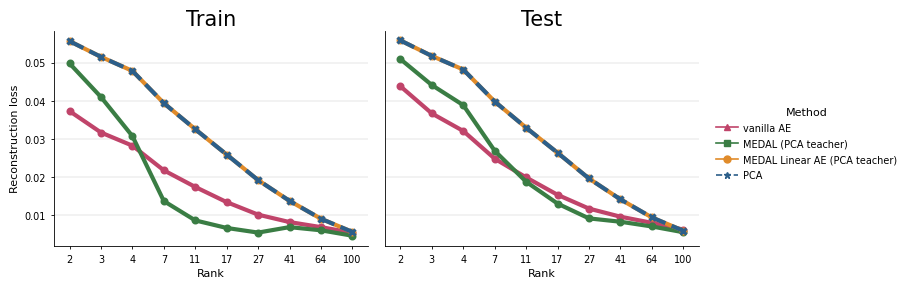

In [8]:


analysis      = pd.DataFrame(mnist_res_dict)
analysis      = analysis[~analysis.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]
analysis_test = pd.DataFrame(mnist_test_res_dict)
analysis_test = analysis_test[~analysis_test.method.isin(["MEDAL + UMAP", "MEDAL + Spectral"])]

# PNAS 2-column figure width ≈ 7 inches; 4 panels → 3.5 wide, modest height
fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=True)

for ax, data, title in zip(axes,
                            [analysis, analysis_test],
                            ['Train', 'Test']):
    # Non-PCA methods
    sns.pointplot(
        data=data[data['method'] != 'PCA'],
        x='n_components', y='recon_loss',
        hue='method', palette=palette,
        errorbar='se', err_kws={'linewidth': 0.6},
        markersize=3.5, linewidth=3,
        dodge=False, legend=False, ax=ax,
    )
    # PCA — dashed + x marker
    sns.pointplot(
        data=data[data['method'] == 'PCA'],
        x='n_components', y='recon_loss',
        hue='method', palette=palette,
        markersize=4, linewidth=3,
        legend=False, ax=ax,
        markers='x', linestyles='--',
    )

    # Spine cleanup — keep only left + bottom
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_linewidth(0.6)

    # Subtle horizontal gridlines only
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', linewidth=0.35, color='gray', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    ax.set_title(title, pad=4, fontsize=15)
    ax.set_xlabel("Rank", labelpad=3)

axes[0].set_ylabel("Reconstruction loss", labelpad=3)
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', left=False)

# Clean legend with correct marker styles
legend_handles = []
for method, color in palette.items():
    ls = '--' if method == 'PCA' else '-'
    mk = markers[method]
    legend_handles.append(
        Line2D([0], [0],
               color=color, marker=mk,
               markersize=5, linewidth=1.2,
               linestyle=ls, label=method)
    )

fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title='Method',
    handlelength=2.2,
    handletextpad=0.5,
    borderpad=0,
    labelspacing=0.6,
)

plt.tight_layout(pad=0.5, w_pad=1.5)
# plt.savefig('figure.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
gene_cancer_res_dict = []
gene_cancer_test_res_dict = []
X, X_test, y, y_test = load_and_split("gene_cancer", test_size=0.2, seed=0, labels=True)
for s in range(1):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 10).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/vanillaAE_{c}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=c, batchnorm=True)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        gene_cancer_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "vanilla AE"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/medal_umap{c}_5_0.1_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=c, batchnorm=True)
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL + UMAP"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        gene_cancer_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL + UMAP"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})
        X_hat = pca.inverse_transform(pca.transform(X_test))
        test_recon = ((X_test - X_hat)**2).mean()
        gene_cancer_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/medal_pca{c}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000, 1000, 1000, 1000],
                latent_dim=c, batchnorm=True)
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL + PCA"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        gene_cancer_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL + PCA"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/medal_spectral{c}_5_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000,1000,1000,1000],
                latent_dim=c, batchnorm=True)
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL + Spectral"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        gene_cancer_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL + Spectral"})

        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/gene_cancer/linearAE_pca{c}_{s}_ckpts/final.pt",
                input_dim=20531,
                hidden_dims=[1000,1000,1000,1000],
                latent_dim=c, activation=None, batchnorm=True)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "MEDAL Linear AE + PCA"})
        x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
        test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
        gene_cancer_test_res_dict.append({"n_components": c, "recon_loss": test_recon, "seed": s, "method": "MEDAL Linear AE + PCA"})

encoder layers: Sequential(
  (0): Linear(in_features=20531, out_features=1000, bias=True)
  (1): SELU()
  (2): Linear(in_features=1000, out_features=1000, bias=True)
  (3): SELU()
  (4): Linear(in_features=1000, out_features=1000, bias=True)
  (5): SELU()
  (6): Linear(in_features=1000, out_features=1000, bias=True)
  (7): SELU()
  (8): Linear(in_features=1000, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1000, bias=True), BatchNorm1d(1000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), SELU(), Dropout(p=0.1, inplace=False), Linear(in_features=1000, out_features=1000, bias=True), BatchNorm1d(1000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), SELU(), Dropout(p=0.1, inplace=False), Linear(in_features=1000, out_features=1000, bias=True), BatchNorm1d(1000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), SELU(), Dropout(p=0.1, inplace=False), Linear(in_features=1000, out_features=1000, bias=True), Ba

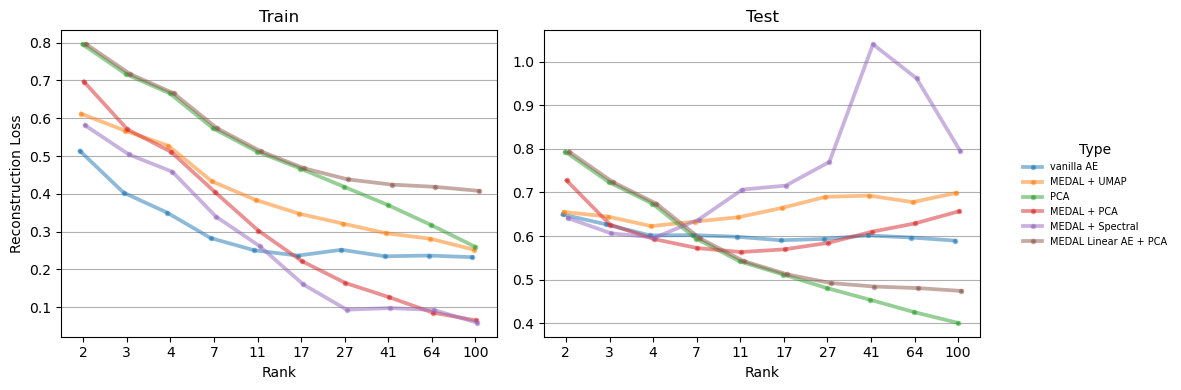

In [17]:
analysis = pd.DataFrame(gene_cancer_res_dict)
analysis_test = pd.DataFrame(gene_cancer_test_res_dict)
fig, axes = plt.subplots(1,2,figsize=(10,4), sharex=True)
sns.pointplot(data=analysis_test, x='n_components', y='recon_loss', hue='method', errorbar=None, markersize=2, alpha=0.5, dodge=True, legend=False, ax=axes[1])
sns.pointplot(data=analysis, x='n_components', y='recon_loss', hue='method', errorbar=None, markersize=2, alpha=0.5, dodge=True, ax=axes[0])
# axes[1].set_yscale("log")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
# make one shared legend for the whole figure
fig.legend(
    handles, labels,
    loc='center', bbox_to_anchor=(1.1, 0.5), 
    frameon=False, title='Type', ncol=1, fontsize=7
)

axes[0].set_xlabel("Rank")
axes[0].set_title("Train")
axes[0].grid(axis='y')
axes[0].set_ylabel("Reconstruction Loss")
axes[1].set_xlabel("Rank")
axes[1].set_title("Test")
axes[1].grid(axis='y')
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [9]:
hydra_res_dict = []
X, X_test, y, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
for s in range(1):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 15).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/vanillaAE_{c}_{s}_ckpts/final.pt",
                input_dim=500,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        hydra_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/umap{c}_9_0.1_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000, 1000, 1000, 1000],
        #         latent_dim=c)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + UMAP"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        hydra_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/pca{c}_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000, 1000, 1000, 1000],
        #         latent_dim=c)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + PCA"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/spectral{c}_11_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000,1000,1000,1000],
        #         latent_dim=c)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + Spectral"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/linearAE_pca{c}_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000,1000,1000,1000],
        #         latent_dim=c, activation=None)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained Linear AE + PCA"})

encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=500, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=500, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (

In [28]:
!ls shared/share_mala/irchang/drd/tmp_results/chkpt/

ls: cannot access 'shared/share_mala/irchang/drd/tmp_results/chkpt/': No such file or directory


In [ ]:
analysis = pd.DataFrame(gene_cancer_res_dict)
sns.pointplot(data=analysis, x='n_components', y='recon_loss', hue='method', errorbar=None, markersize=2, alpha=0.5, dodge=True)
# make one shared legend for the whole figure
plt.legend(
    loc='center', bbox_to_anchor=(1.2, 0.5), 
    frameon=False, title='Type', ncol=1, fontsize=7
)
plt.xticks(rotation=30, fontsize=7, ha='right')
plt.xlabel("Rank")
plt.show()

In [27]:
tasic_res_dict = []
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
for s in range(1):
    for c in np.unique(np.logspace(np.log10(2), np.log10(100), 15).astype(int)):
        student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/cortical/vanillaAE_{c}_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=c)
        
        student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        tasic_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "vanilla AE"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/umap{c}_9_0.1_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000, 1000, 1000, 1000],
        #         latent_dim=c)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + UMAP"})

        pca = PCA(n_components=c).fit(X)
        X_hat = pca.inverse_transform(pca.transform(X))
        train_recon = ((X - X_hat)**2).mean()
        tasic_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "PCA"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/pca{c}_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000, 1000, 1000, 1000],
        #         latent_dim=c)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + PCA"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/spectral{c}_11_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000,1000,1000,1000],
        #         latent_dim=c)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained + Spectral"})

        # student = load_trained_ae(Path(PATH_PREFIX) / f"tmp_results/chkpt/hydra/linearAE_pca{c}_{s}_ckpts/final.pt",
        #         input_dim=20531,
        #         hidden_dims=[1000,1000,1000,1000],
        #         latent_dim=c, activation=None)
        
        # student_recon, _ = student(torch.tensor(X, dtype=torch.float32))
        # train_recon = np.mean((student_recon.detach().numpy() - X)**2)
        # gene_cancer_res_dict.append({"n_components": c, "recon_loss": train_recon, "seed": s, "method": "Constrained Linear AE + PCA"})

encoder layers: Sequential(
  (0): Linear(in_features=1000, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)
  (5): SELU()
  (6): Linear(in_features=1792, out_features=1792, bias=True)
  (7): SELU()
  (8): Linear(in_features=1792, out_features=2, bias=True)
)
decoder layers: [Linear(in_features=2, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=1792, bias=True), SELU(), Linear(in_features=1792, out_features=309, bias=True), SELU(), Linear(in_features=309, out_features=1000, bias=True)]
loaded params: 20 | missing=0 | unexpected=0
encoder layers: Sequential(
  (0): Linear(in_features=1000, out_features=309, bias=True)
  (1): SELU()
  (2): Linear(in_features=309, out_features=1792, bias=True)
  (3): SELU()
  (4): Linear(in_features=1792, out_features=1792, bias=True)


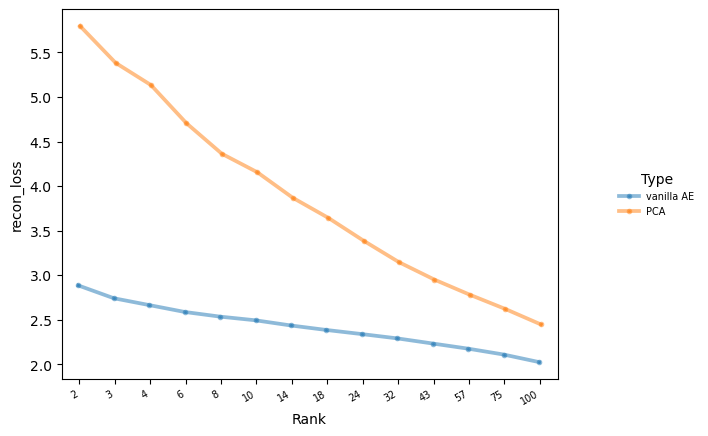

In [29]:
analysis = pd.DataFrame(tasic_res_dict)
sns.pointplot(data=analysis, x='n_components', y='recon_loss', hue='method', errorbar=None, markersize=2, alpha=0.5, dodge=True)
# make one shared legend for the whole figure
plt.legend(
    loc='center', bbox_to_anchor=(1.2, 0.5), 
    frameon=False, title='Type', ncol=1, fontsize=7
)
plt.xticks(rotation=30, fontsize=7, ha='right')
plt.xlabel("Rank")
plt.show()

## Wine data
<!-- Red arrow = No activation, Green arrow = SELU activation

![](architecture_diagram.png) -->

In [ ]:
analysis = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/wine.csv')
df = analysis[columnss]
df = df.sort_values(by='recon_loss')
pd.set_option('display.float_format', '{:.6e}'.format)
(df
  .style
  .background_gradient(subset=["distill_loss","recon_loss","time_total_s"],
                       cmap="viridis")
  .format({"distill_loss":"{:.6e}"})
  .set_caption("Hyperparameter Results"))

,distill_loss,recon_loss,time_total_s,config/teacher_config/teacher,config/teacher_config/t_n_neighbors,config/teacher_config/min_dist,config/teacher_config/perplexity,config/teacher_config/learning_rate
7,2.261013e-10,0.099482,1970.469585,tsne,nan,nan,30.000000,300.000000
9,1.173212e-09,0.101209,1895.327933,tsne,nan,nan,50.000000,300.000000
6,2.158119e-10,0.109476,1891.452716,tsne,nan,nan,30.000000,200.000000
8,6.889334e-10,0.109478,1972.391455,tsne,nan,nan,50.000000,200.000000
2,9.253214e-09,0.136924,3780.565160,umap,15.000000,0.010000,nan,nan
1,5.260019e-09,0.138552,3778.257993,umap,10.000000,0.100000,nan,nan
0,1.075634e-08,0.139695,3773.828948,umap,10.000000,0.010000,nan,nan
4,6.128851e-09,0.140989,3781.976525,umap,20.000000,0.010000,nan,nan
3,4.609693e-09,0.144554,3781.753117,umap,15.000000,0.100000,nan,nan
5,4.939715e-09,0.151676,3780.990306,umap,20.000000,0.100000,nan,nan


## MNIST data

<!-- Red arrow = No activation, Green arrow = SELU activation

![](architecture_diagram.png) -->

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_mnist_from_scratch.csv')
# analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_from_scratch2.csv')
# analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.distill_loss < 0.1]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_mnist_from_pretrained.csv')
# analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist_from_pretrained2.csv')
# analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_110985/3406543892.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_110985/3406543892.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_110985/3138892948.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_110985/3138892948.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


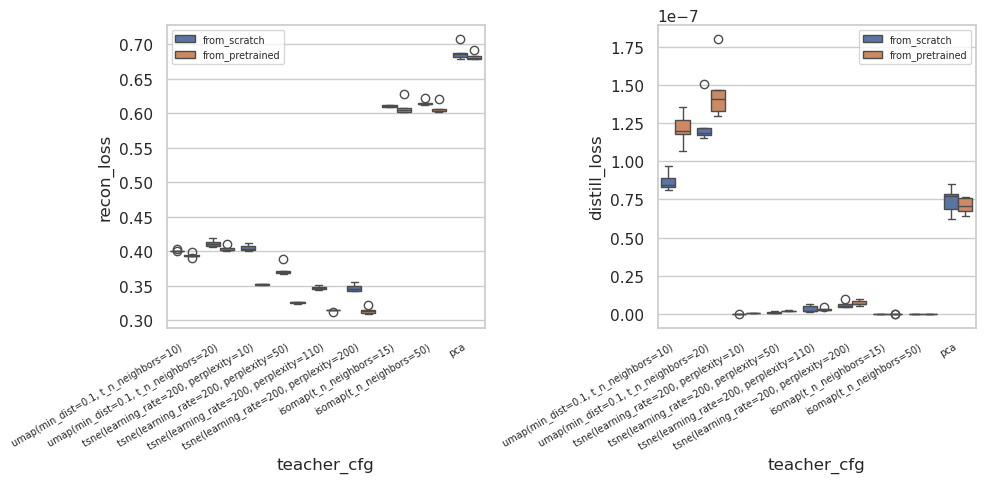

In [ ]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_114026/3873201064.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_114026/3873201064.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'
/tmp/ipykernel_114026/3873201064.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right'

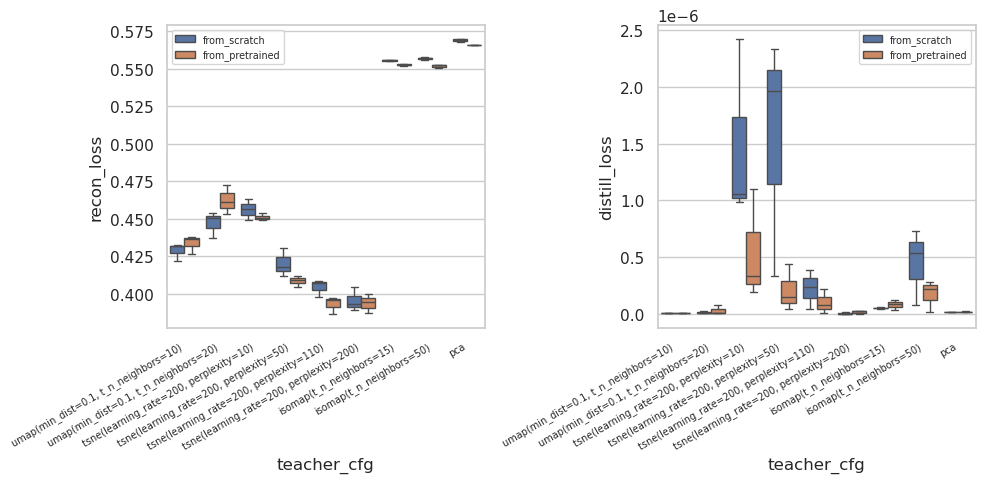

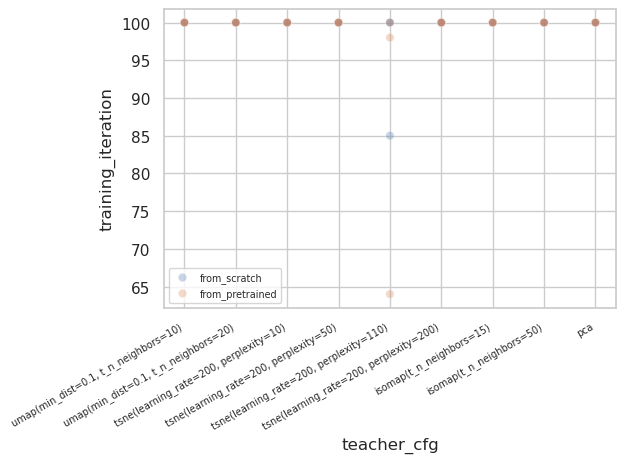

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist1k_from_scratch.csv')
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/mnist1k_from_pretrained.csv')
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

sns.scatterplot(data=analysis_both, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting', alpha=0.3)
plt.xticks(rotation=30, fontsize=7, ha='right')
plt.legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

## Single Cell data

<!-- ![](architecture_diagram.png) -->

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_scratch.csv')
analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_scratch2.csv')
analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)
# analysis_from_scratch = analysis_from_scratch[analysis_from_scratch.training_iteration < 100]
param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_pretrained.csv')
analysis_from_pretrained2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/single_cell_from_pretrained2.csv')
analysis_from_pretrained = pd.concat([analysis_from_pretrained, analysis_from_pretrained2], ignore_index=True)
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.training_iteration < 100]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
analysis = pd.concat([df_scratch, df_pretrained], ignore_index=True)

/tmp/ipykernel_118885/1430140271.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_118885/1430140271.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'


/tmp/ipykernel_118885/2818806538.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/2818806538.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


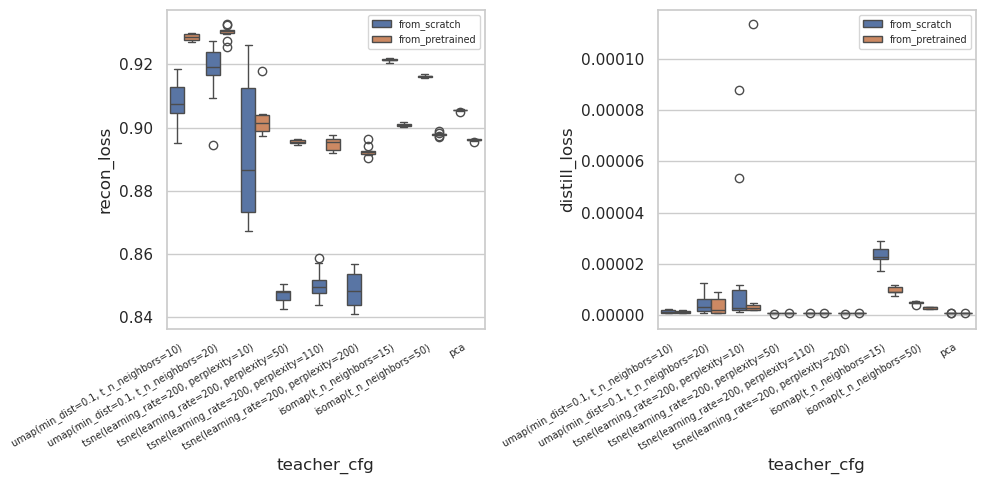

In [ ]:
present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0), 'teacher_cfg']
analysis_both_sc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_118885/403697329.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
/tmp/ipykernel_118885/403697329.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')


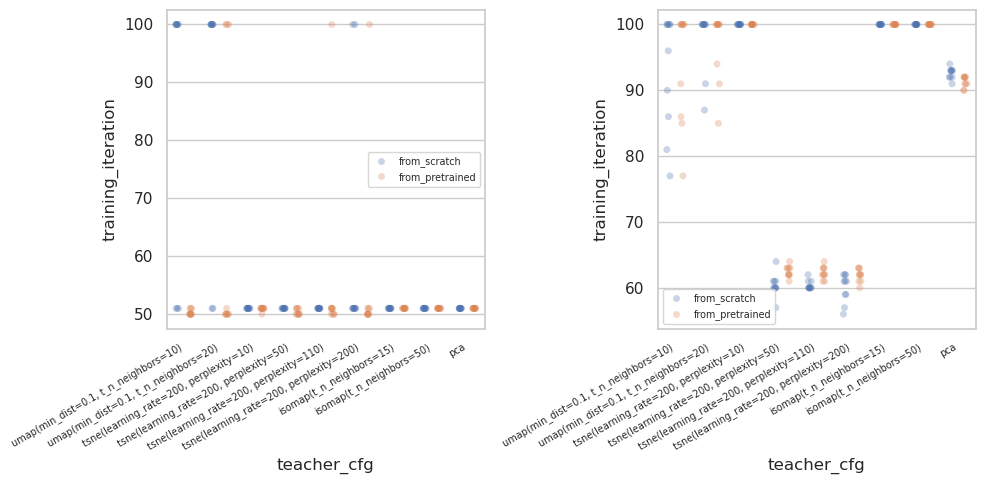

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.stripplot(data=analysis_both_pc, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting', alpha=0.3, ax = axes[0], dodge=True)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.stripplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'training_iteration', hue = 'setting',alpha=0.3, ax = axes[1], dodge=True)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()
plt.show()

/tmp/ipykernel_110985/3152137547.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scratch['setting'] = 'from_scratch'
/tmp/ipykernel_110985/3152137547.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pretrained['setting'] = 'from_pretrained'
/tmp/ipykernel_110985/3152137547.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

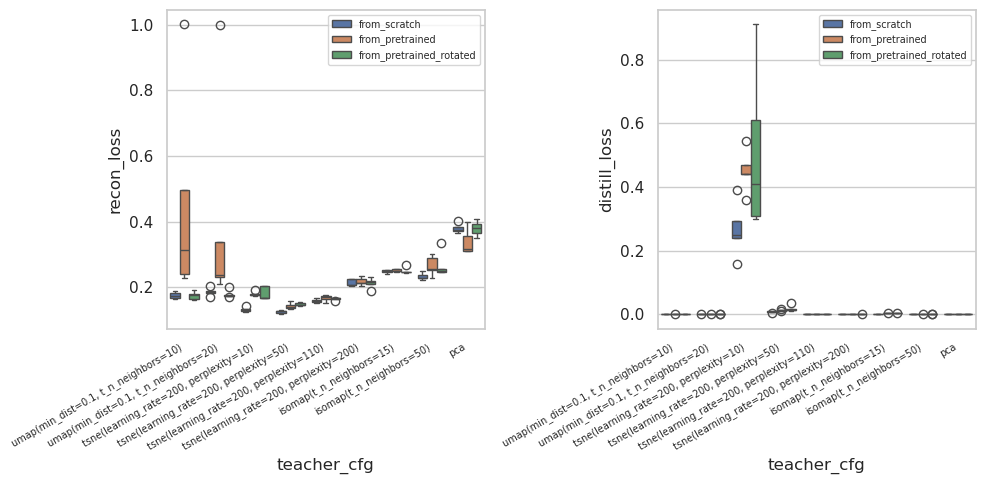

In [ ]:
analysis_from_scratch = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_scratch.csv')
# analysis_from_scratch2 = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_scratch2.csv')
# analysis_from_scratch = pd.concat([analysis_from_scratch, analysis_from_scratch2], ignore_index=True)

param_cols = [c for c in analysis_from_scratch.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_scratch['teacher_cfg'] = analysis_from_scratch.apply(make_label, param_cols = param_cols, axis=1)
df_scratch = analysis_from_scratch[columnss]

analysis_from_pretrained = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/diabetes_from_pretrained.csv')
# analysis_from_pretrained = analysis_from_pretrained[analysis_from_pretrained.distill_loss < 0.01]
param_cols = [c for c in analysis_from_pretrained.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained['teacher_cfg'] = analysis_from_pretrained.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained = analysis_from_pretrained[columnss]

analysis_from_pretrained_rot = pd.read_csv('/shared/share_mala/irchang/drd/compare_teachers/rot_diabetes_from_pretrained.csv')
analysis_from_pretrained_rot = analysis_from_pretrained_rot[analysis_from_pretrained_rot.distill_loss < 1]
param_cols = [c for c in analysis_from_pretrained_rot.columns if c.startswith(prefix) and c != teacher_col]
analysis_from_pretrained_rot['teacher_cfg'] = analysis_from_pretrained_rot.apply(make_label, param_cols = param_cols, axis=1)
df_pretrained_rot = analysis_from_pretrained_rot[columnss]

df_scratch['setting'] = 'from_scratch'
df_pretrained['setting'] = 'from_pretrained'
df_pretrained_rot['setting'] = 'from_pretrained_rotated'
analysis = pd.concat([df_scratch, df_pretrained, df_pretrained_rot], ignore_index=True)

present = (analysis.groupby(['teacher_cfg','setting']).size().unstack(fill_value=0)).reset_index()
keep_cfgs = present.loc[(present['from_pretrained'] > 0) & (present['from_scratch'] > 0) & (present['from_pretrained_rotated'] > 0), 'teacher_cfg']
analysis_both_sc = analysis[analysis['teacher_cfg'].isin(keep_cfgs)].copy()

# set grid
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.set_theme(style="whitegrid")
sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'recon_loss', hue = 'setting', ax = axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[0].legend(fontsize='xx-small')

sns.boxplot(data=analysis_both_sc, x = 'teacher_cfg', y = 'distill_loss', hue = 'setting', ax = axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, fontsize=7, ha='right')
axes[1].legend(fontsize='xx-small')
plt.tight_layout()

plt.show()